In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from sklearn.datasets import make_regression
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import tqdm
from uncertainty_explainer.uq_explainer import (
    UncertaintyExplanationPipeline
)

2026-03-27 10:55:38.324 | INFO     | uncertainty_explainer.config:<module>:11 - PROJ_ROOT path is: C:\Users\VerónicaSeguroVarela\Documents\Projects\uncertainty-explainer
c:\Users\VerónicaSeguroVarela\Documents\Projects\uncertainty-explainer\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
X, y = make_regression(
n_samples=200,
n_features=5,
noise=0.1,
)

In [5]:
X_train = X[:120]
y_train = y[:120]

X_calib = X[120:160]
y_calib = y[120:160]

X_test = X[160:]

# model = RandomForestRegressor()

# pipeline = (
#     UncertaintyExplanationPipeline(model)
# )



In [7]:
X_test[:, 0]

array([ 0.74174712, -0.97356965, -0.29647408, -1.87822439, -0.35335301,
       -0.03157756,  1.54340287, -1.07396084, -0.52623646,  0.7466876 ,
        0.67312964,  0.55108514,  0.81037775, -1.96549088, -0.13415084,
       -1.34531953, -0.38428607,  0.53388967, -0.49821567,  0.01751765,
       -0.89932694, -0.32139149,  0.49906252,  0.12303859, -1.70024934,
        0.49259873, -0.02384848, -2.3771556 ,  0.12273991, -0.22082453,
        0.55832253,  0.47878331, -1.41245616,  1.7184012 ,  1.01719712,
        1.6199556 ,  1.29778462, -0.21244308, -0.85763041,  0.4831522 ])

## Test

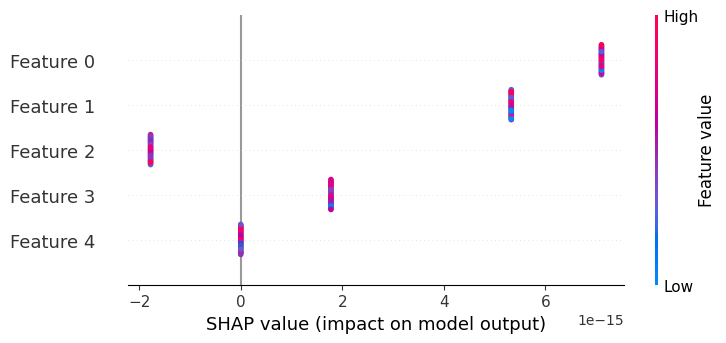

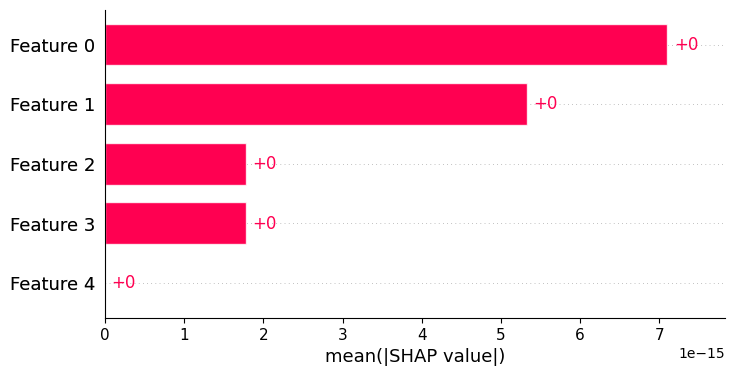

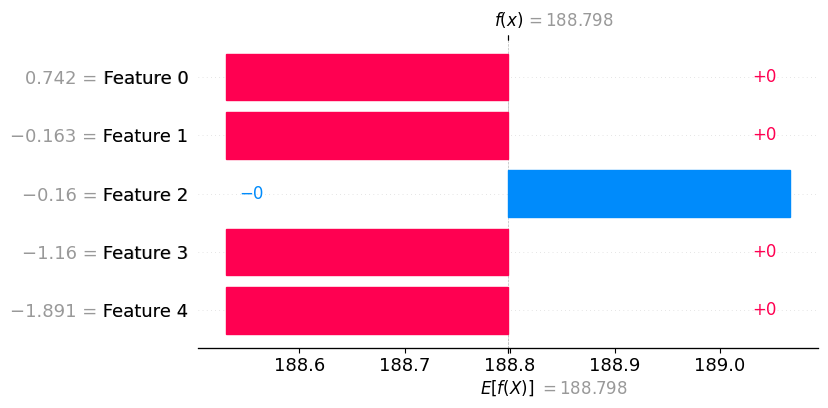

In [11]:
from sklearn.ensemble import RandomForestRegressor
from uncertainty_explainer.uq_explainer import (
    UncertaintyExplanationPipeline
)

pipeline = UncertaintyExplanationPipeline(
    RandomForestRegressor()
)

pipeline.fit(
    X_train,
    y_train,
    X_calib,
    y_calib,
)

result = pipeline.explain_uncertainty(
    X_test
)

In [13]:
result['interval_width']

array([188.79845264, 188.79845264, 188.79845264, 188.79845264,
       188.79845264, 188.79845264, 188.79845264, 188.79845264,
       188.79845264, 188.79845264, 188.79845264, 188.79845264,
       188.79845264, 188.79845264, 188.79845264, 188.79845264,
       188.79845264, 188.79845264, 188.79845264, 188.79845264,
       188.79845264, 188.79845264, 188.79845264, 188.79845264,
       188.79845264, 188.79845264, 188.79845264, 188.79845264,
       188.79845264, 188.79845264, 188.79845264, 188.79845264,
       188.79845264, 188.79845264, 188.79845264, 188.79845264,
       188.79845264, 188.79845264, 188.79845264, 188.79845264])

## Exemplo 2

In [11]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from crepes import WrapRegressor
dataset = fetch_openml(name="house_sales", version=3, parser="auto")

X = dataset.data.values.astype(float)
y = dataset.target.values.astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05)
X_prop_train, X_cal, y_prop_train, y_cal = train_test_split(X_train, y_train,
                                                            test_size=0.25)

In [12]:
pipeline = UncertaintyExplanationPipeline(
    RandomForestRegressor()
)

pipeline.fit(
    X_prop_train,
    y_prop_train,
    X_cal,
    y_cal,
)

# result = pipeline.explain_uncertainty(
#     X_test
# )

In [13]:
X_test

array([[5.000e+00, 2.750e+00, 2.930e+03, ..., 2.014e+03, 1.000e+01,
        3.000e+00],
       [2.000e+00, 1.000e+00, 1.170e+03, ..., 2.014e+03, 8.000e+00,
        2.000e+01],
       [4.000e+00, 2.250e+00, 2.460e+03, ..., 2.014e+03, 6.000e+00,
        2.500e+01],
       ...,
       [4.000e+00, 2.500e+00, 3.270e+03, ..., 2.014e+03, 6.000e+00,
        1.200e+01],
       [3.000e+00, 2.750e+00, 3.610e+03, ..., 2.015e+03, 3.000e+00,
        1.300e+01],
       [3.000e+00, 1.750e+00, 1.060e+03, ..., 2.015e+03, 1.000e+00,
        5.000e+00]], shape=(1081, 21))

PermutationExplainer explainer: 1082it [11:05,  1.60it/s]                          


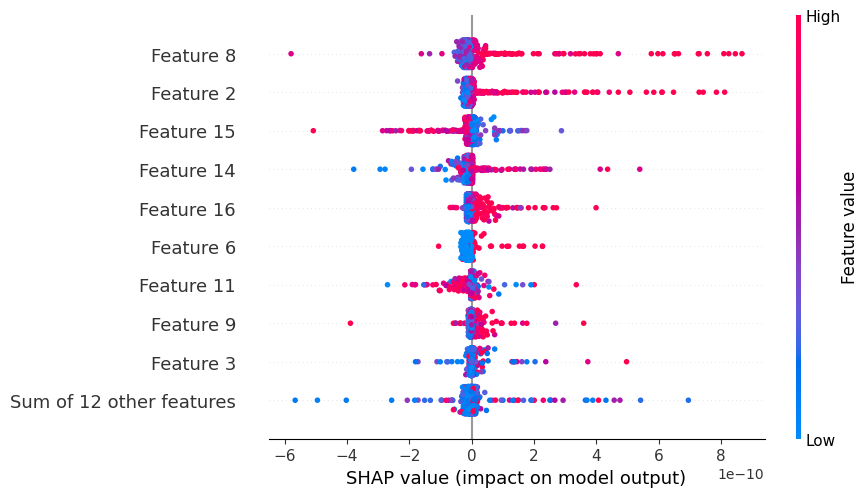

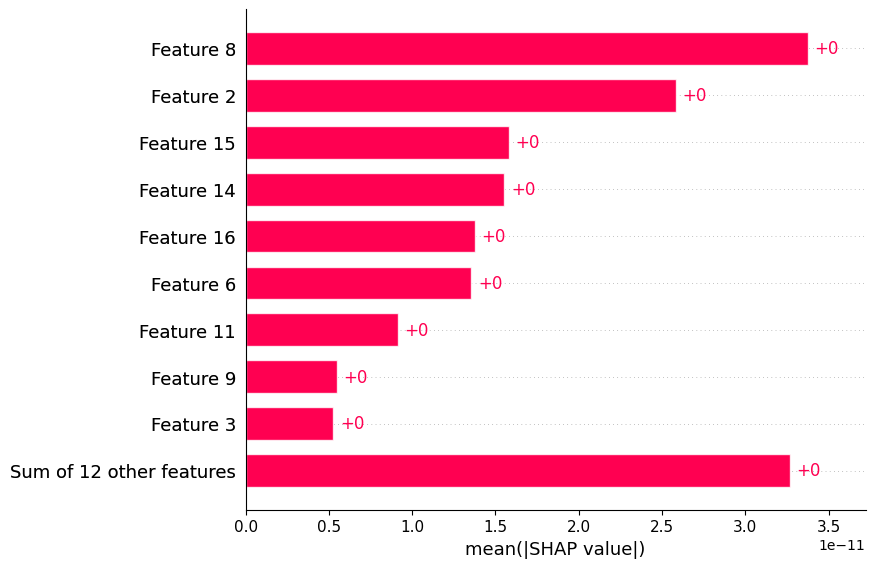

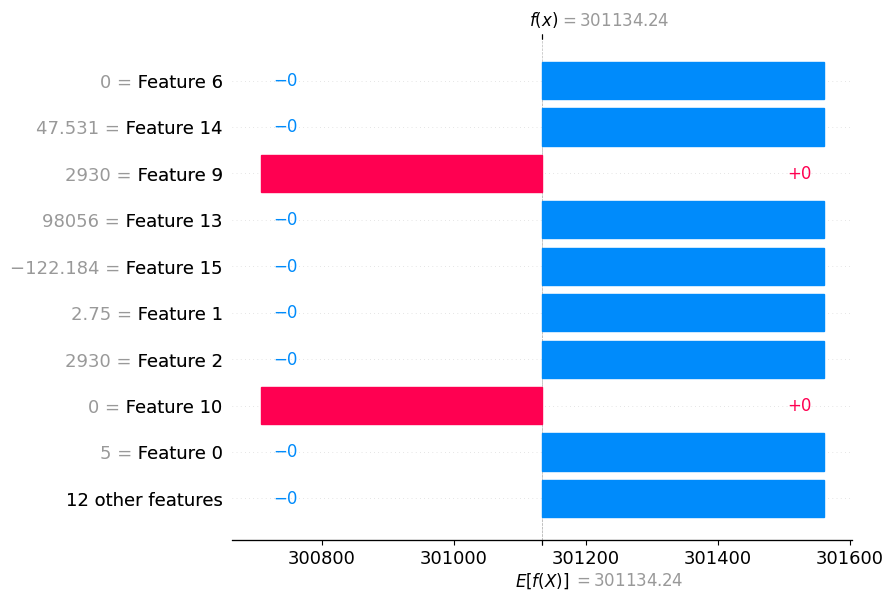

In [14]:
result = pipeline.explain_uncertainty(
    X_test,
    algorithm="permutation"
)

In [15]:
X_test

array([[5.000e+00, 2.750e+00, 2.930e+03, ..., 2.014e+03, 1.000e+01,
        3.000e+00],
       [2.000e+00, 1.000e+00, 1.170e+03, ..., 2.014e+03, 8.000e+00,
        2.000e+01],
       [4.000e+00, 2.250e+00, 2.460e+03, ..., 2.014e+03, 6.000e+00,
        2.500e+01],
       ...,
       [4.000e+00, 2.500e+00, 3.270e+03, ..., 2.014e+03, 6.000e+00,
        1.200e+01],
       [3.000e+00, 2.750e+00, 3.610e+03, ..., 2.015e+03, 3.000e+00,
        1.300e+01],
       [3.000e+00, 1.750e+00, 1.060e+03, ..., 2.015e+03, 1.000e+00,
        5.000e+00]], shape=(1081, 21))